# StormScope Prediction Visualization

This notebook demonstrates how to:
- Load StormScope model outputs (GOES + MRMS)
- Select specific forecast steps
- Visualize predicted vs observed fields

Key dimensions used throughout:
- **batch**: sample index
- **time**: initialization time
- **lead_time**: forecast horizon
- **variable**: channel or meteorological variable

/gpfsm/dnb34/jli30/QEFM/qefm-core/notebooks


In [1]:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import pandas as pd

## Load Model Output Data

We load prediction datasets generated from StormScope.
These datasets typically contain multi-dimensional arrays with:
(batch, time, lead_time, variable, lat, lon)

In [2]:
init_time = [np.datetime64("2024-09-28T12:00:00")]
ts_str = pd.to_datetime(init_time[0]).strftime("%Y%m%d_%H%M%S")
goes_variables =  ['abi01c', 'abi02c', 'abi03c', 'abi07c', 'abi08c', 'abi09c', 'abi10c', 'abi13c']
goes_channel = "abi13c"
mrms_channel = "refc"
goes_ch_idx = goes_variables.index(goes_channel)
mrms_ch_idx = 0 # mrms prediction single variable "refc"

In [3]:
# Load datasets (GOES + MRMS)
file = f"/discover/nobackup/projects/imvi-nse/jli30/sc_gpu/Helene/stormscope_goes_forecast_{ts_str}.nc"
ds_goes = xr.open_dataset(file)
file = f"/discover/nobackup/projects/imvi-nse/jli30/sc_gpu/Helene/stormscope_mrms_forecast_{ts_str}.nc"
ds_mrms = xr.open_dataset(file)

In [4]:
# Inspect structure
ds_goes

<xarray.Dataset> Size: 88MB
Dimensions:          (batch: 1, time: 1, lead_time: 6, variable: 8, y: 512,
                      x: 896)
Coordinates:
  * batch            (batch) int64 8B 0
  * time             (time) datetime64[ns] 8B 2024-09-28T12:00:00
  * lead_time        (lead_time) timedelta64[ns] 48B 01:00:00 ... 06:00:00
  * variable         (variable) <U6 192B 'abi01c' 'abi02c' ... 'abi10c' 'abi13c'
  * y                (y) float64 4kB -1.536e+06 -1.53e+06 ... 1.524e+06 1.53e+06
  * x                (x) float64 7kB -2.689e+06 -2.683e+06 ... 2.681e+06
Data variables:
    stormscope_goes  (batch, time, lead_time, variable, y, x) float32 88MB ...

## Select a Specific Forecast Slice

We extract a single example for visualization:
- First batch
- First initialization time
- Specific forecast lead time
- Selected variable/channel

In [5]:
# Extract one sample
field_goes = ds_goes["stormscope_goes"].isel(
    batch=0,        # first sample
    time=0,         # first init time
    lead_time=1,    # forecast step (e.g., +2 hr)
    variable=goes_ch_idx # goes_channel "abi13c"
)

# Extract MRMS 
field_mrms = ds_mrms["stormscope_mrms"].isel(
    batch=0,
    time=0,
    lead_time=1,
    variable=0      # typically single variable "refc"
)

## Visualization

We compare:
- GOES-based prediction (model output)
- MRMS

Note:
- MRMS values typically represent reflectivity (dBZ)
- Proper colormap scaling is important for interpretation

Text(0.5, 1.0, 'Predicted GOES abi13c \n from 20240928_120000 UTC initialization (lead 2:00:00)')

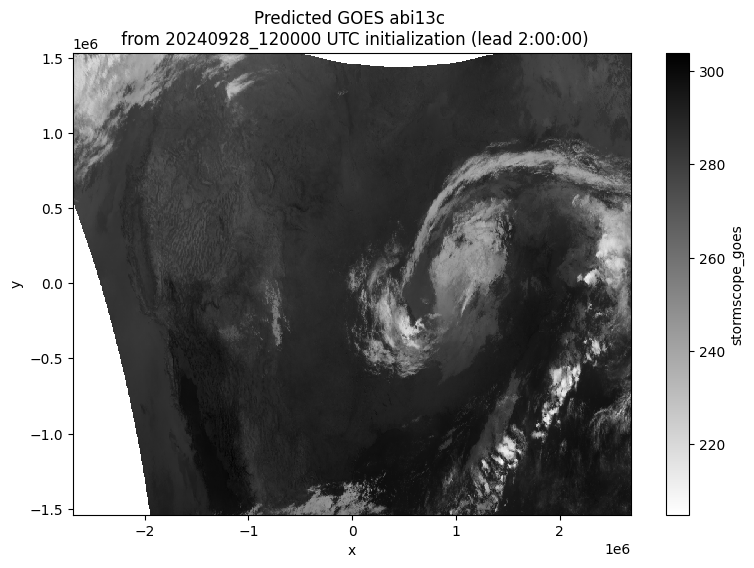

In [6]:
# Plot GOES field
plt.figure(figsize=(9, 6))
field_goes.plot(cmap='gray_r')
lead_time = field_goes.lead_time.values
plt.title(
    f"Predicted GOES {goes_channel} \n from {ts_str} UTC "
    f"initialization (lead {lead_time.astype('timedelta64[h]').item()})"
)

Text(0.5, 1.0, 'Predicted MRMS refc \n from 20240928_120000 UTC initialization (lead 2:00:00)')

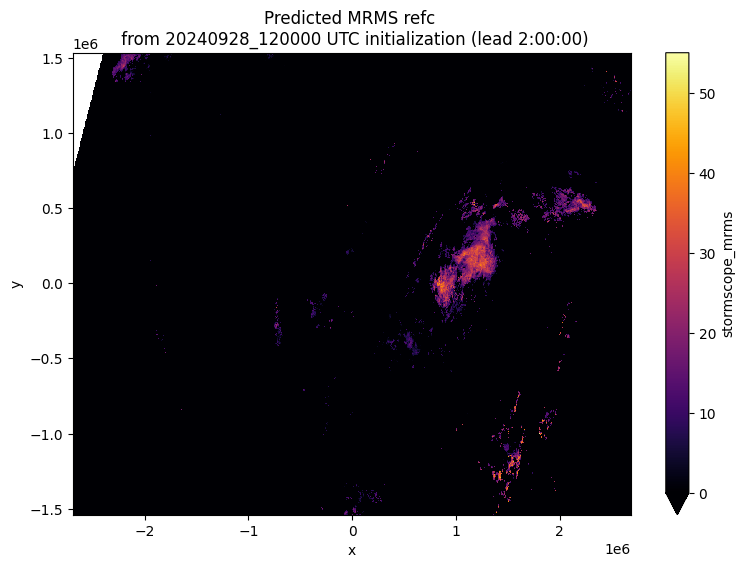

In [7]:
# Plot MRMS field
plt.figure(figsize=(9, 6))
field_mrms.plot(cmap='inferno', vmin=0.0, vmax=55.0)
lead_time = field_mrms.lead_time.values
plt.title(
    f"Predicted MRMS {mrms_channel} \n from {ts_str} UTC "
    f"initialization (lead {lead_time.astype('timedelta64[h]').item()})"
)